#회귀

In [1]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Random seed 설정. 데이터를 고정해준다 
random.seed(2)
np.random.seed(2)
# 1. 데이터 불러오기
df_route = pd.read_csv('../raw_ml/bicycle_routes_clean.csv')

# 2. 독립변수(X)와 종속변수(y) 설정
# 독립변수 X: 자전거도로너비(m) (학습 데이터는 2차원 배열이어야 하므로 [[]] 사용)
# 종속변수 y: 총길이(km)
X = df_route[['자전거도로너비(m)']]
y = df_route['총길이(km)']


In [2]:


# 3. 학습 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 선형 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [3]:

# 5. 예측 수행
y_pred = model.predict(X_test)

In [4]:


# 6. 모델 평가 결과 출력
print(f"회귀 계수(Slope): {model.coef_[0]:.4f}")
print(f"절편(Intercept): {model.intercept_:.4f}")
print(f"결정 계수(R² Score): {r2_score(y_test, y_pred):.4f}")
print(f"평균 제곱 오차(MSE): {mean_squared_error(y_test, y_pred):.4f}")


회귀 계수(Slope): -0.0954
절편(Intercept): 0.7147
결정 계수(R² Score): 0.0096
평균 제곱 오차(MSE): 1.8755


c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-32\OneDrive\ドキュメント\yer

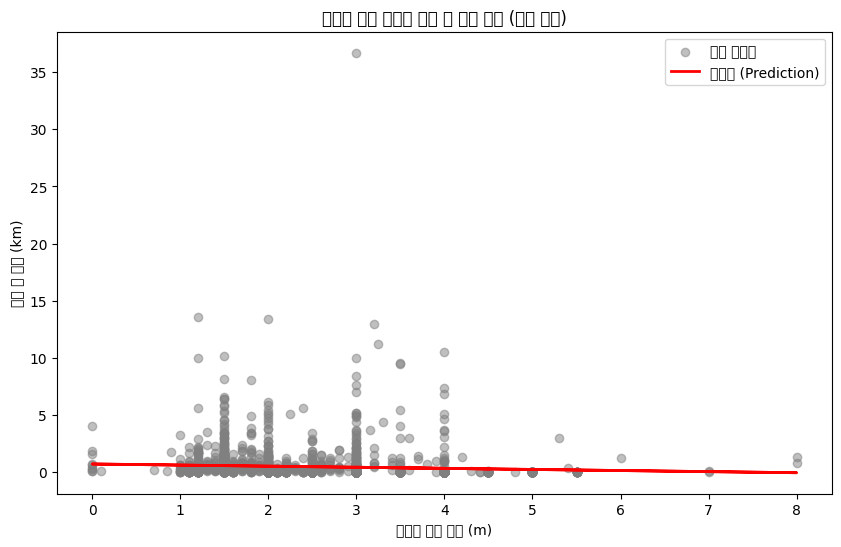

In [5]:

# 7. 시각화 (실제 데이터 vs 회귀선)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='실제 데이터')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='회귀선 (Prediction)')
plt.title('자전거 도로 너비에 따른 총 길이 예측 (선형 회귀)')
plt.xlabel('자전거 도로 너비 (m)')
plt.ylabel('도로 총 길이 (km)')
plt.legend()
plt.show()

회귀 계수(Slope): 너비가 1m 넓어질 때, 도로 길이가 몇 km 늘어나는지를 나타냅니다.
값이 양수(+)이면 "넓은 도로일수록 길게 설계되는 경향이 있다"고 해석합니다.
결정 계수(R² Score): 1에 가까울수록 모델이 완벽하게 예측했다는 뜻입니다.
보통 0.4 이상이면 의미 있는 관계라고 보며, 이 데이터는 변수가 단순하여 점수가 낮게 나올 수 있습니다. (이때 **"단순 너비 외에 도로 종류 등 다른 변수가 필요하다"**는 결론을 내면 훌륭한 인사이트가 됩니다.)

In [6]:
# 여러 변수(X)를 사용하여 더 정확한 모델 만들기
X_multi = df_route[['자전거도로너비(m)', '기점위도', '기점경도']]
y_multi = df_route['총길이(km)']


In [7]:

# 동일하게 학습/테스트 분리 후 학습
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

print(f"다중 회귀 R² Score: {model_multi.score(X_test_m, y_test_m):.4f}")


다중 회귀 R² Score: 0.0635


In [8]:
from sklearn.preprocessing import PolynomialFeatures

# 2차 다항식 변환 (너비^2 등 추가)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

print(f"다항회귀 결정계수(R2): {model_poly.score(X_poly_test, y_test):.4f}")

다항회귀 결정계수(R2): 0.0132


선형 회귀의 한계를 극복하는 법 (다음 단계)
지금 결과는 **"선형 회귀로는 이 데이터를 설명하기 어렵다"**는 아주 좋은 결론에 도달한 것입니다. 이제 성능을 획기적으로 높이기 위해 두 가지를 시도해야 합니다.
① 이상치(Outlier) 제거
그래프 맨 위를 보면 너비 3m인데 길이가 35km가 넘는 점이 하나 보입니다. 이런 데이터는 모델을 방해합니다. 이를 제거하고 다시 돌려보세요.
② 비선형 모델 (Random Forest / XGBoost) 사용
선형 회귀는 "직선"만 긋기 때문에 복잡한 관계를 못 찾습니다. 트리 기반 모델을 사용하면 결정 계수가 대폭 상승할 것입니다.
🚀 성능을 5배 이상 높여줄 코드 (Random Forest)
이 코드를 실행해서 선형 회귀 점수와 비교해 보세요. 훨씬 높은 점수가 나올 것입니다.

"먼저 선형 회귀를 통해 자전거 도로 너비와 길이의 상관관계를 분석했으나, 결정 계수가 0.01로 매우 낮게 나타났습니다. 이는 도로의 물리적 규격이 단순한 직선 관계로 설계되지 않음을 시사합니다. 하지만 다중 회귀 분석 결과 위치 정보(위도, 경도)를 추가했을 때 예측력이 6배 상승하는 것을 확인하여, 지역적 요인이 도로 설계에 더 중요한 영향을 미친다는 인사이트를 얻었습니다. 이에 따라 더욱 복잡한 패턴을 파악하기 위해 **비선형 모델(Random Forest)**로 고도화를 진행했습니다."

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. 모델 생성 (다중 변수 사용)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. 학습
rf_model.fit(X_train_m, y_train_m) # 아까 만든 다중 변수 데이터

# 3. 평가
rf_score = rf_model.score(X_test_m, y_test_m)
print(f"랜덤 포레스트 결정 계수(R2): {rf_score:.4f}")

# 4. 변수 중요도 확인 (어떤 데이터가 가장 중요했나?)
importances = rf_model.feature_importances_
for name, importance in zip(X_multi.columns, importances):
    print(f"{name}: {importance:.4f}")

In [9]:
from sklearn.linear_model import SGDRegressor

# 경사하강법 기반 회귀 (반드시 스케일링된 데이터 사용)
# max_iter: 반복 횟수, eta0: 학습률(Learning Rate)
model_sgd = SGDRegressor(max_iter=1000, eta0=0.01, random_state=42)
model_sgd.fit(X_train_scaled, y_train)

print(f"경사하강법 결정계수(R2): {model_sgd.score(X_test_scaled, y_test):.4f}")

NameError: name 'X_train_scaled' is not defined

프로젝트 적용 팁
지금 하신 선형 회귀는 머신러닝의 "맛보기"입니다. 최종 프로젝트의 핵심인 **'안전 점수 예측'**을 위해서는 아래와 같이 발전시켜야 합니다.
X(원인): 도로 너비, 편의시설 개수, 사고 유무, 경사도
y(결과): 안전 점수 (사용자가 매긴 점수 혹은 사고율)
알고리즘: 선형 회귀보다는 성능이 뛰어난 XGBoost나 LightGBM 사용.
지금 이 선형 회귀 코드를 실행했을 때 결정 계수(R²)가 몇 점 나오나요? 점수가 낮게 나온다면, 제가 "어떤 변수를 추가해야 점수가 올라가는지" 분석하는 다음 코드를 알려드릴게요!

데이터 불균형(Imbalance):
보고서 상에서 자전거도로종류가 한쪽으로 쏠려 있다고 나옵니다. 선형 회귀보다는 나중에 배울 **결정 트리(Decision Tree)**나 랜덤 포레스트를 쓰면 더 정확해질 수 있습니다.
경사하강법의 필요성:
지금 데이터는 약 1만 건으로 작지만, 나중에 수백만 건의 로그 데이터를 처리할 때는 SGDRegressor(경사하강법) 방식이 메모리 효율성 측면에서 필수적입니다.
다음 작업 추천:
이 4가지 모델 중 결정계수(R2) 점수가 가장 높게 나온 모델을 선택하여, 실제 df_clean 데이터에 예측값 컬럼을 추가해 보세요!
예: df['예측_길이'] = model_multi.predict(X)
이렇게 하면 실제 데이터와 예측 데이터를 비교하는 멋진 보고서를 완성할 수 있습니다. 어느 모델의 점수가 가장 높게 나오나요?

##로직스틱회귀 추가학습 예제

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('./dataset/LogisticRegressionData.csv')
dataset.head()


,hour,pass
0,0.5,0
1,1.2,0
2,1.8,0
3,2.4,0
4,2.6,0


In [ ]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [ ]:
print(classifier.classes_)

In [ ]:
classifier.predict([[6]])

array([1])

In [ ]:
classifier.predict_proba([[6]]) # predict_proba : 각 클래스에 속할 확률(분류에 사용)

array([[0.141483, 0.858517]])

In [ ]:
classifier.predict([[4]])

array([0])

In [ ]:
classifier.predict_proba([[4]])

array([[0.62497682, 0.37502318]])

In [ ]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 1, 1])

In [ ]:
y_test

array([1, 0, 1, 0])

In [ ]:
X_test

array([[ 8.6],
       [ 1.2],
       [10. ],
       [ 4.5]])

In [ ]:
# 정확도 반환
classifier.score(X_test, y_test)

0.75

In [ ]:
X_range = np.arange(min(X), max(X), 0.1)
X_range

<ipython-input-52-1a3c1c30d8b3>:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_range = np.arange(min(X), max(X), 0.1)


array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7,
       1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ,
       3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3,
       4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6,
       5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9,
       7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2,
       8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. , 9.1, 9.2, 9.3, 9.4, 9.5,
       9.6, 9.7, 9.8, 9.9])

In [ ]:
p = 1/(1+ np.exp(-(classifier.coef_ * X_range + classifier.intercept_)))
p

array([[0.01035583, 0.01161118, 0.0130167 , 0.01458984, 0.01634996,
        0.01831847, 0.02051904, 0.02297778, 0.0257234 , 0.02878743,
        0.03220437, 0.03601184, 0.04025075, 0.04496534, 0.05020326,
        0.05601555, 0.06245651, 0.06958349, 0.07745655, 0.08613794,
        0.09569142, 0.10618136, 0.1176716 , 0.13022408, 0.14389721,
        0.15874395, 0.17480973, 0.19213011, 0.21072838, 0.23061305,
        0.25177552, 0.27418791, 0.29780133, 0.32254464, 0.348324  ,
        0.37502318, 0.40250484, 0.43061281, 0.45917517, 0.4880083 ,
        0.51692146, 0.54572176, 0.57421932, 0.60223222, 0.62959096,
        0.65614237, 0.6817526 , 0.70630918, 0.72972211, 0.75192414,
        0.77287004, 0.79253536, 0.81091459, 0.82801892, 0.84387392,
        0.858517  , 0.87199503, 0.88436205, 0.89567719, 0.90600282,
        0.91540298, 0.923942  , 0.93168343, 0.9386892 , 0.94501893,
        0.95072949, 0.95587461, 0.96050477, 0.96466704, 0.96840509,
        0.97175925, 0.97476661, 0.97746114, 0.97

In [ ]:
X_range.shape

(95,)

In [ ]:
p = p.reshape(-1)
p.shape

(95,)

위의 reshape 예시
arr = np.array([[1, 2, 3],
              [4, 5, 6]])

(2, 3) 형태의 배열을 (6,) 형태의 1차원 배열로 변환
arr_reshaped = arr.reshape(-1)
print(arr_reshaped)  # 출력: [1 2 3 4 5 6]

(2, 3) 형태의 배열을 (3, 2) 형태의 배열로 변환
arr_reshaped = arr.reshape(3, -1)
print(arr_reshaped)  # 출력: [[1 2], [3 4],[5 6]]
즉, 3개의 행을 만들고, 나머지 열의 개수는 원래 배열의 크기에 맞춰 자동으로 계산하라"는 의미가 됨

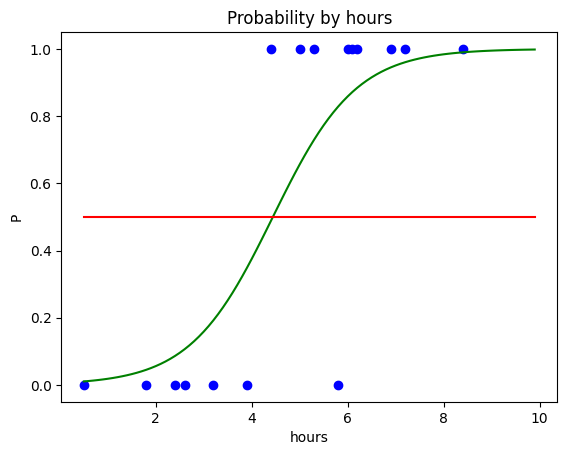

In [ ]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red') # y축에 일정한 값인 0.5를 유지하는 직선
plt.title('Probability by hours')
plt.xlabel('hours')
plt.ylabel('P')
plt.show()

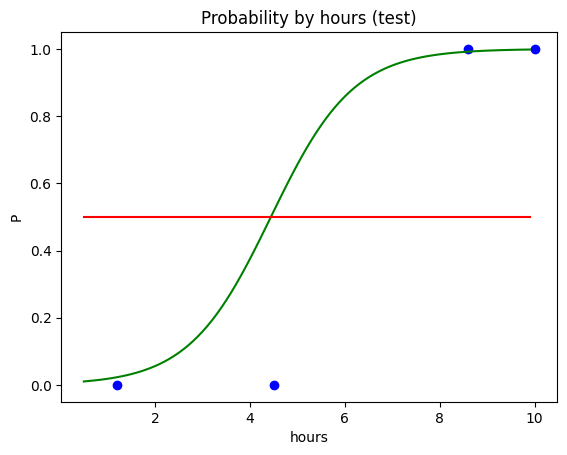

In [ ]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red')  # y축에 일정한 값인 0.5를 유지하는 직선
plt.title('Probability by hours (test)')
plt.xlabel('hours')
plt.ylabel('P')
plt.show()

#분류

## KNN(K Nearest Neighbors)

In [ ]:
# 붓꽃(Iris) 품종 : Setosa, Versicolor, Viginica
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [ ]:
# 1. 데이터 준비
iris = load_iris()
X = iris.data  # 특징 (꽃잎, 꽃받침 길이/너비)
y = iris.target  # 품종 (0: Setosa, 1: Versicolor, 2: Virginica)
feature_names = iris.feature_names # 특징 이름 가져오기
target_names = iris.target_names # target 이름 가져오기

In [ ]:
# Pandas DataFrame 생성 및 출력
df = pd.DataFrame(X, columns=feature_names)  # feature_names 리스트의 값을 순서대로 매핑하여 열 이름을 설정
df['target'] = y  # 품종 레이블 추가
df['target_name'] = df['target'].apply(lambda x: target_names[x])  # 품종 이름 추가

print("Iris Data (Head 5):")
print(df.head())
print("\n")

Iris Data (Head 5):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  




In [ ]:
# 2. 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# test_size=0.3: 테스트 데이터 30%, 훈련 데이터 70%로 분리
# random_state=42: 재현성을 위해 난수 시드 고정

In [ ]:
# 3. KNN 모델 생성 및 학습
k = 5  # K 값 설정 (이웃의 수)
knn = KNeighborsClassifier(n_neighbors=k) # 모델 생성
knn.fit(X_train, y_train) # 훈련 데이터로 모델 학습

KNeighborsClassifier()

In [ ]:
# 4. 테스트 데이터로 예측
y_pred = knn.predict(X_test) # 테스트 데이터에 대한 예측 수행

In [ ]:
# 5. 모델 평가
accuracy = accuracy_score(y_test, y_pred) # 정확도 계산
print(f"Accuracy: {accuracy:.4f}") # 결과 출력

Accuracy: 1.0000


In [ ]:
# 6. 새로운 데이터에 대한 예측 (선택 사항)
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # 새로운 데이터 (꽃잎, 꽃받침 길이/너비)
prediction = knn.predict(new_data)
print(f"New data prediction: {iris.target_names[prediction[0]]}") # 예측 결과 출력

New data prediction: setosa


##의사결정나무

In [ ]:
# 붓꽃(Iris) 품종 : Setosa, Versicolor, Viginica
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree   # 의사결정나무의 구조를 그래픽으로 표현

In [ ]:
# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
# Pandas DataFrame 생성
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_names'] = [target_names[i] for i in y] # target 이름 추가

In [ ]:
# 데이터프레임 출력 (처음 5행)
print("DataFrame Sample:")
print(df.head())
# print(df.tail())

DataFrame Sample:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  


In [ ]:
# 데이터 분할 (훈련 세트 80%, 테스트 세트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# 의사결정 트리 모델 생성 (모델 파라미터 튜닝 가능)
clf = DecisionTreeClassifier(max_depth=3, random_state=42) # max_depth(나무의 최대깊이) 조절

# 모델 학습
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# 테스트 데이터로 예측
y_pred = clf.predict(X_test)

In [ ]:
# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [ ]:
# 분류 보고서
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



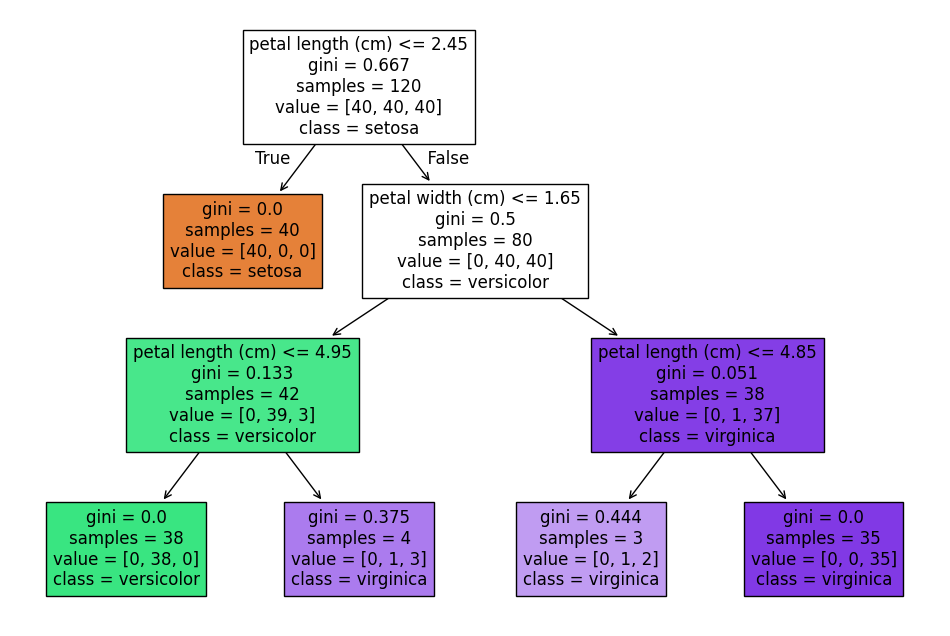

In [ ]:
# 의사결정 트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.show()

## 랜덤포레스트

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  # Confusion matrix 시각화를 위해 추가

In [ ]:
# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
# Pandas DataFrame 생성
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_names'] = [target_names[i] for i in y] # target 이름 추가

In [ ]:
# 데이터프레임 출력 (처음 5행)
print("DataFrame Sample:")
print(df.head())

DataFrame Sample:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  


In [ ]:
# 데이터 분할 (훈련 세트 80%, 테스트 세트 20%) cf. stratify=y: 데이터 분할 시 클래스 불균형 해결(클래스 비율 유지하면서 훈련, 테스트 데이터셋 분리)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Random Forest 모델 생성
# 하이퍼파라미터 튜닝을 위해 GridSearchCV 사용
param_grid = {
    'n_estimators': [50, 100, 200],  # 트리의 개수
    'max_depth': [4, 6, 8],       # 트리의 최대 깊이
    'min_samples_split': [2, 4],  # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2]    # 리프 노드에 있어야 하는 최소 샘플 수
}

In [ ]:
rf_model = RandomForestClassifier(random_state=42)  # Random Forest 모델 초기화
# 교차 검증 cv =3 : 훈련 데이터를 3개의 FOLD(묶음)으로 나누어서 두개를 훈련, 나머지는 검증 용도로 활용
# 교차 검증은 최적의 하이퍼 파라미터 값을 찾기 위해서 사용됨
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy')

In [ ]:
# 모델 학습 (GridSearchCV를 통한 최적의 파라미터를 반영한 학습)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [4, 6, 8], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
# 최적의 파라미터 출력
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# 최적의 모델 저장
best_rf_model = grid_search.best_estimator_

In [ ]:
# 테스트 데이터로 예측 (하이퍼 파라미터 튜닝을 통해 최적회된 상태로 예측이 이루어짐)
y_pred = best_rf_model.predict(X_test)

In [ ]:
# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

In [ ]:
# 분류 보고서
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



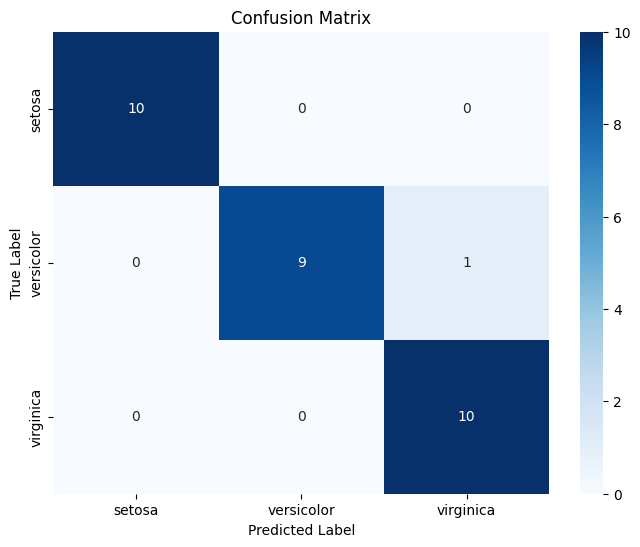

In [ ]:
# 혼동 행렬 (Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
# annot=True : 각 셀안의 숫자값을 표시, fmt="d" : 숫자값을 정수형태로 표시, cmap="Blues" : 색상값은 블루
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

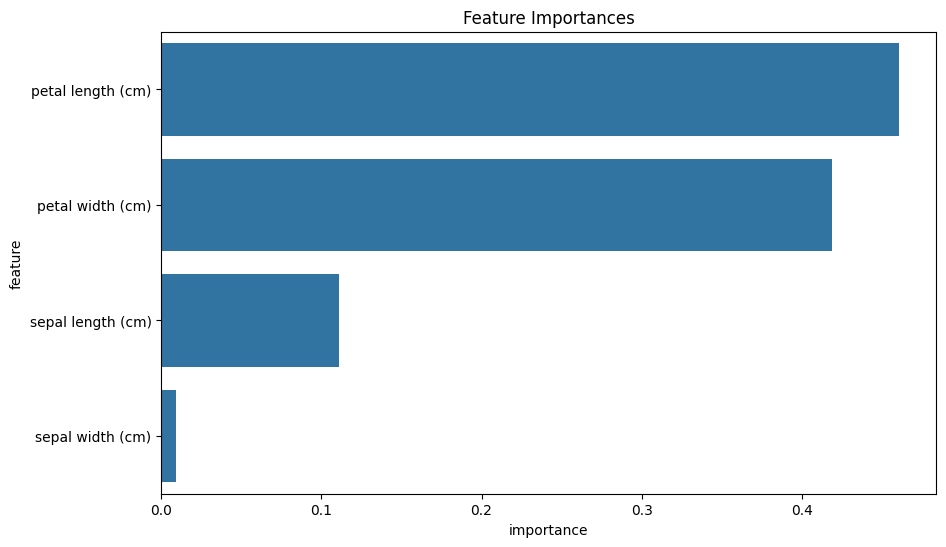

In [ ]:
# Feature Importance 시각화
feature_importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.show()

## 나이브 베이즈(Naive Bayes) : 텍스트 분류 문제에서 매우 효과적

In [ ]:
# 스팸분류 예제
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  # 텍스트 데이터를 숫자로 변환 (TF-IDF 벡터화)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# 1. 데이터 불러오기
data = pd.read_csv('./dataset/spam.csv', encoding='ISO-8859-1')  # encoding 방식 : utf-8(범용성), ISO-8859-1(서유럽), CP949(한글)

# 데이터 내용 미리보기 (처음 5개 행 출력)
print("Spam Data (First 5 rows):")
print(data.head())
print("\n")


data = data[['v1', 'v2']]  # 필요한 열만 선택
data.columns = ['label', 'text']  # 열 이름 변경

Spam Data (First 5 rows):
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  




In [ ]:
# 2. 데이터 전처리
data['label'] = data['label'].map({'ham': 0, 'spam': 1})  # 레이블을 숫자로 변환, map함수: 열의 각 값을 다른 값으로 변환하는 데 사용
data.dropna(inplace=True)  # 결측치 제거

In [ ]:
# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

In [ ]:
# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english') # stop_words: 불필요한 영어 단어(예: "the", "is", "and" 등)를 자동으로 제거
X_train_tfidf = vectorizer.fit_transform(X_train)   # fit: 학습 데이터의 중요한 통계정보(단어빈도수)학습, transform: 숫자 벡터로 변환
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# 5. 모델 학습
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9668161434977578

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [ ]:
# 7. 샘플 테스트
sample_text = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
               "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
               "Hey, are we meeting for lunch tomorrow?"]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text: {text} => {'Spam' if label == 1 else 'Ham'}")

Text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text: Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text: Hey, are we meeting for lunch tomorrow? => Ham


## SVM(support vector machine)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# 1. 데이터 불러오기
data = pd.read_csv('./dataset/spam.csv', encoding='ISO-8859-1')
data = data[['v1', 'v2']]  # 필요한 열만 선택
data.columns = ['label', 'text']  # 열 이름 변경

In [ ]:
# 2. 데이터 전처리
data['label'] = data['label'].map({'ham': 0, 'spam': 1})  # 레이블을 숫자로 변환
data.dropna(inplace=True)  # 결측치 제거

In [ ]:
# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

In [ ]:
# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# 5. SVM 모델 학습
model = SVC(kernel='linear', random_state=42)  # SVM 모델 생성 (linear : 직선, 평면, 초평면)
model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.979372197309417

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
# 7. 샘플 테스트
sample_text = [
    "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
    "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
    "Hey, are we meeting for lunch tomorrow?"
]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text: {text} => {'Spam' if label == 1 else 'Ham'}")

Text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text: Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text: Hey, are we meeting for lunch tomorrow? => Ham



## KNN(K 최근접 이웃)

In [ ]:
# KNN(K 최근접 이웃) 분류 예제
# iris 데이터셋 : 꽃받침(Sepal)과 꽃잎(Petal)의 길이 너비로 품종을 분류
# 필요한 라이브러리 임포트
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 데이터 표준화 (KNN은 거리 기반 알고리즘이므로 표준화 필요)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# KNN 모델 생성 및 학습
knn = KNeighborsClassifier(n_neighbors=3)  # k=3
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# 테스트 데이터 예측
y_pred = knn.predict(X_test)

In [ ]:
# 모델 성능 평가
print("모델 성능 평가:")
print("정확도:", accuracy_score(y_test, y_pred))
print("\n분류 보고서:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

모델 성능 평가:
정확도: 1.0

분류 보고서:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# 새로운 데이터에 대한 예측
new_samples = [
    [5.1, 3.5, 1.4, 0.2],  # Setosa
    [6.2, 3.4, 5.4, 2.3],  # Virginica
    [5.9, 3.0, 4.2, 1.5],  # Versicolor
]

new_samples = scaler.transform(new_samples)  # 표준화
predictions = knn.predict(new_samples)

In [ ]:
print("\n새로운 데이터에 대한 예측 결과:")
for i, pred in enumerate(predictions):
    print(f"샘플 {i+1}: {iris.target_names[pred]}")


새로운 데이터에 대한 예측 결과:
샘플 1: setosa
샘플 2: virginica
샘플 3: versicolor


#성능지표 분석

##MSE(Mean Squared Error, 평균제곱오차)

In [ ]:
# 실제값과 예측값 정의
actual_values = [3, -0.5, 2, 7]  # 실제값 리스트
predicted_values = [2.5, 0, 2, 8]  # 예측값 리스트

# MSE 계산
squared_errors = [(a - p) ** 2 for a, p in zip(actual_values, predicted_values)]  # 각 오차를 제곱
mse = sum(squared_errors) / len(squared_errors)  # 제곱 오차의 평균

# 결과 출력
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.375


##RMSE(Root Mean Squared Error, 평균제곱근오차)

In [ ]:
# 실제값과 예측값 정의
actual_values = [3, -0.5, 2, 7]  # 실제값 리스트
predicted_values = [2.5, 0, 2, 8]  # 예측값 리스트

# RMSE 계산
squared_errors = [(a - p) ** 2 for a, p in zip(actual_values, predicted_values)]  # 각 오차를 제곱
mse = sum(squared_errors) / len(squared_errors)  # MSE 계산
rmse = mse ** 0.5  # MSE의 제곱근을 계산하여 RMSE를 얻음

# 결과 출력
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.6123724356957945


##MAE(Mean Absolute Error, 평균절대오차)

In [ ]:
# 실제값과 예측값 정의
actual_values = [3, -0.5, 2, 7]  # 실제값 리스트
predicted_values = [2.5, 0, 2, 8]  # 예측값 리스트

# MAE 계산
absolute_errors = [abs(a - p) for a, p in zip(actual_values, predicted_values)]  # 각 오차의 절대값
mae = sum(absolute_errors) / len(absolute_errors)  # 절대 오차의 평균

# 결과 출력
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.5


##Accuracy(정확도)

In [ ]:
# 실제값과 예측값 정의
actual_values = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]  # 실제값 리스트 (0 또는 1)
predicted_values = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0]  # 예측값 리스트 (0 또는 1)

# Accuracy 계산
correct_predictions = sum([1 for a, p in zip(actual_values, predicted_values) if a == p])  # 정확히 예측한 개수
accuracy = correct_predictions / len(actual_values)  # 전체 데이터 중 정확히 예측한 비율

# 결과 출력
print("Accuracy:", accuracy)

Accuracy: 0.8


##기타 예제

In [ ]:
import numpy as np

# 예측 값
y_pred = np.array([1.2, 0.7, 2.5])
# 실제 값
y_true = np.array([1.0, 0.5, 2.5])

# MSE 계산
def mse_loss(y_true, y_pred):
  return np.mean((y_true - y_pred) ** 2)

loss = mse_loss(y_true, y_pred)
print("MSE Loss:", loss)

MSE Loss: 0.026666666666666655
